# Rainfall Prediction of Kaggle Competition

# **Import Modules**

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# **Load The Dataset**

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# **Data Understanding**

In [4]:
train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
train.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [6]:
train.duplicated().sum()

0

In [7]:
train.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='object')

# Feature Engineering

In [8]:
# Step 1: Add cyclical features
train['wind_dir_sin'] = np.sin(np.deg2rad(train['winddirection']))
train['wind_dir_cos'] = np.cos(np.deg2rad(train['winddirection']))

test['wind_dir_sin'] = np.sin(np.deg2rad(test['winddirection']))
test['wind_dir_cos'] = np.cos(np.deg2rad(test['winddirection']))




In [9]:
train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,wind_dir_sin,wind_dir_cos
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,0.866025,0.500000
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,0.766044,0.642788
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,0.939693,0.342020
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,0.866025,0.500000
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,0.642788,0.766044


In [10]:
train = train.drop(columns=['winddirection'])

test = test.drop(columns=['winddirection'])

In [11]:
train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,wind_dir_sin,wind_dir_cos
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,0.866025,0.500000
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,0.766044,0.642788
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,0.939693,0.342020
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,0.866025,0.500000
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,0.642788,0.766044


# **EDA**

In [12]:
train.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'windspeed', 'rainfall',
       'wind_dir_sin', 'wind_dir_cos'],
      dtype='object')

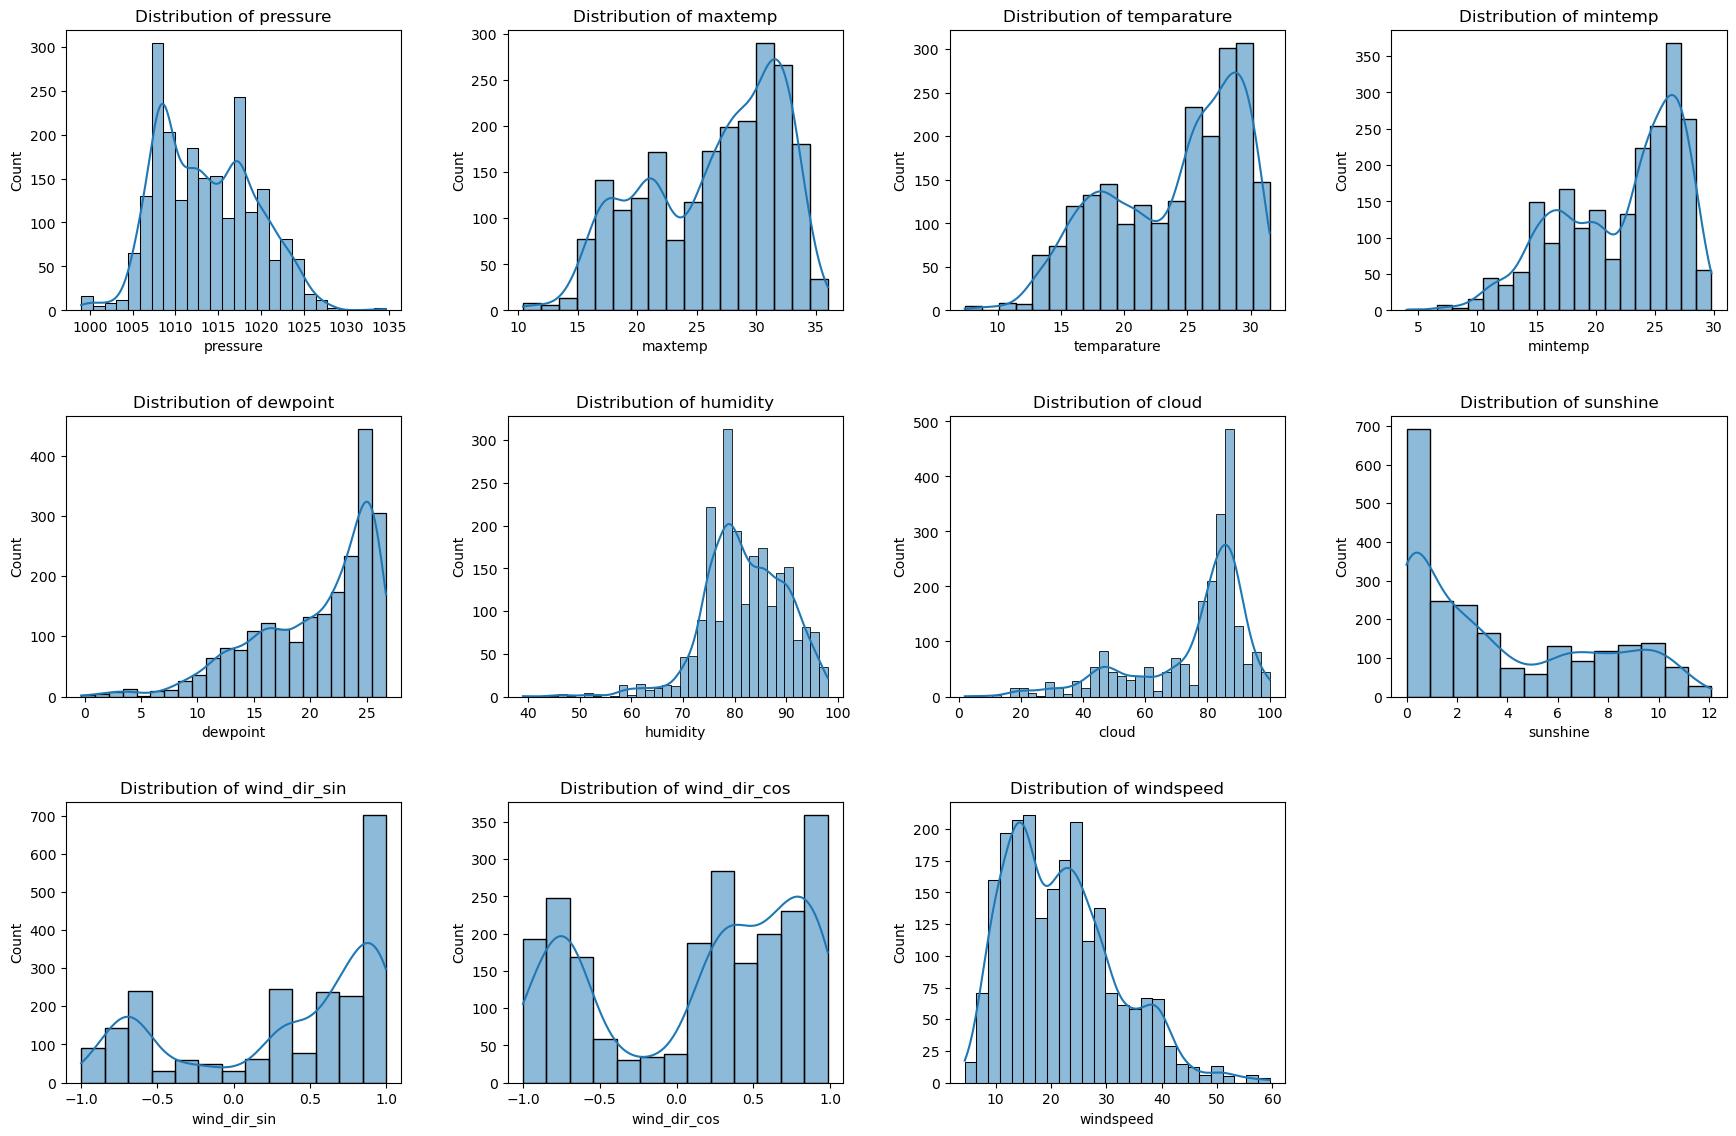

In [13]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'wind_dir_sin', 'wind_dir_cos', 'windspeed']

plt.figure(figsize=(18, 12))

for i, column in enumerate(columns, 1):
    plt.subplot(3,4, i)
    sns.histplot(train[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout(pad=3.0)
plt.show()

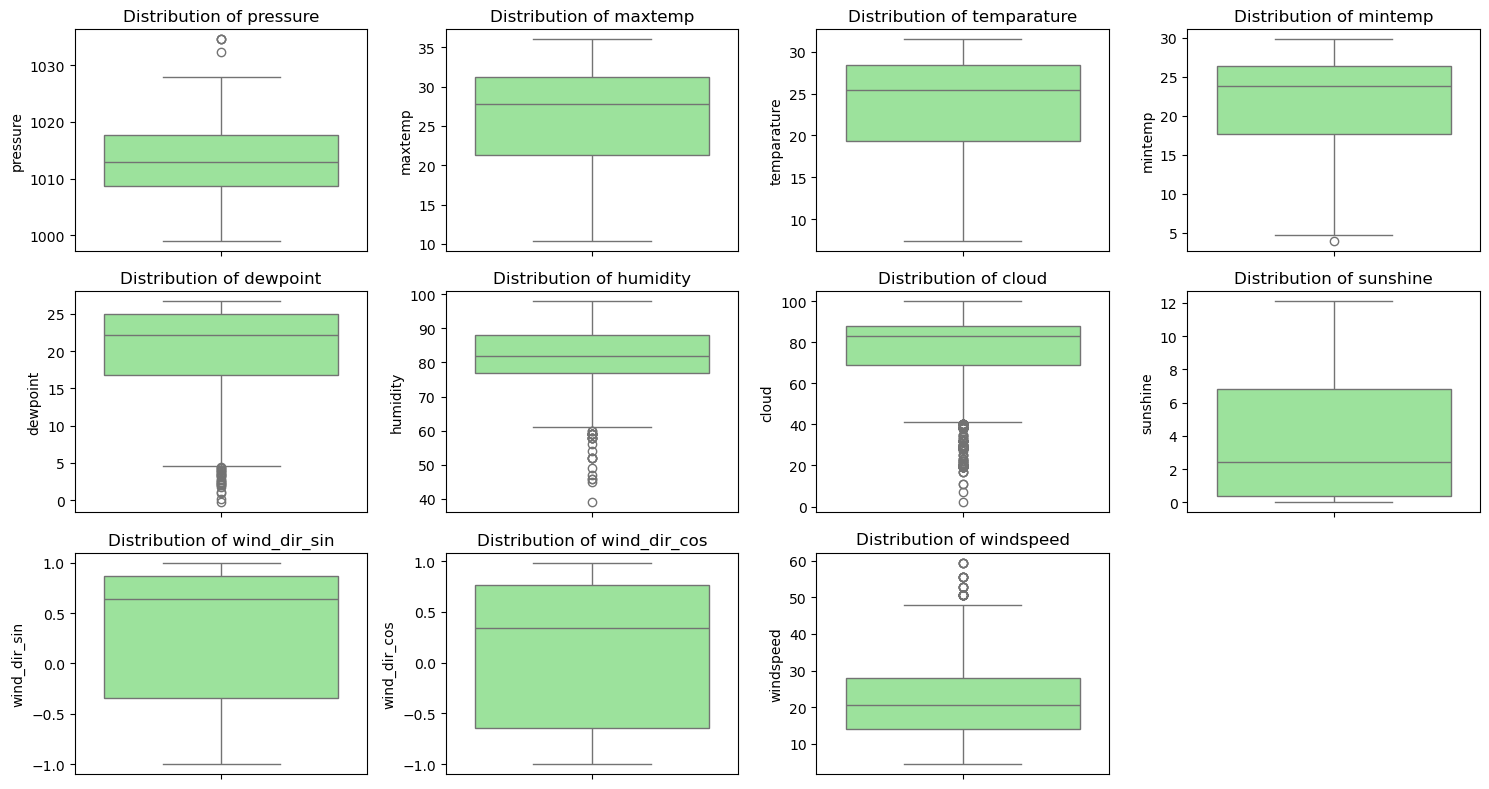

In [14]:
# Box Plot

plt.figure(figsize=(15, 8))

for i, column in  enumerate(columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(train[column], color="lightgreen")
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

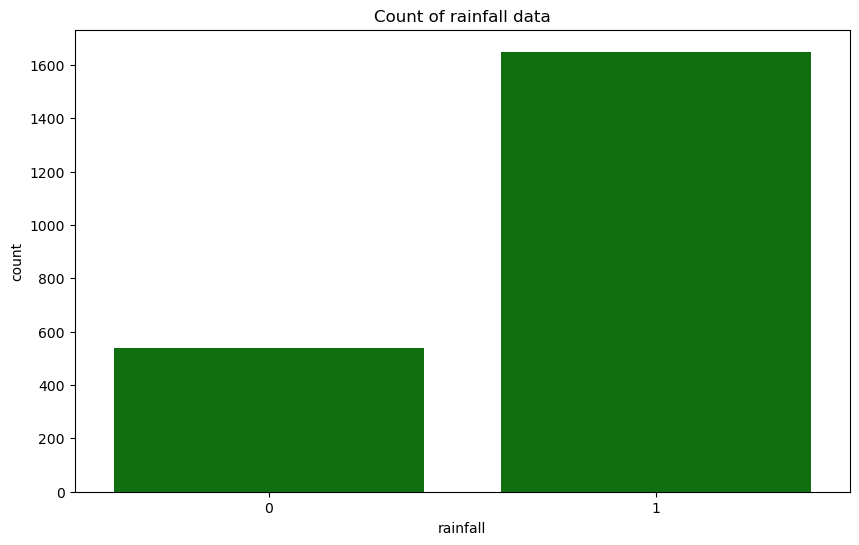

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(x = 'rainfall', data=train, color='green')
plt.title("Count of rainfall data")
plt.show()

- This is Imbalanced

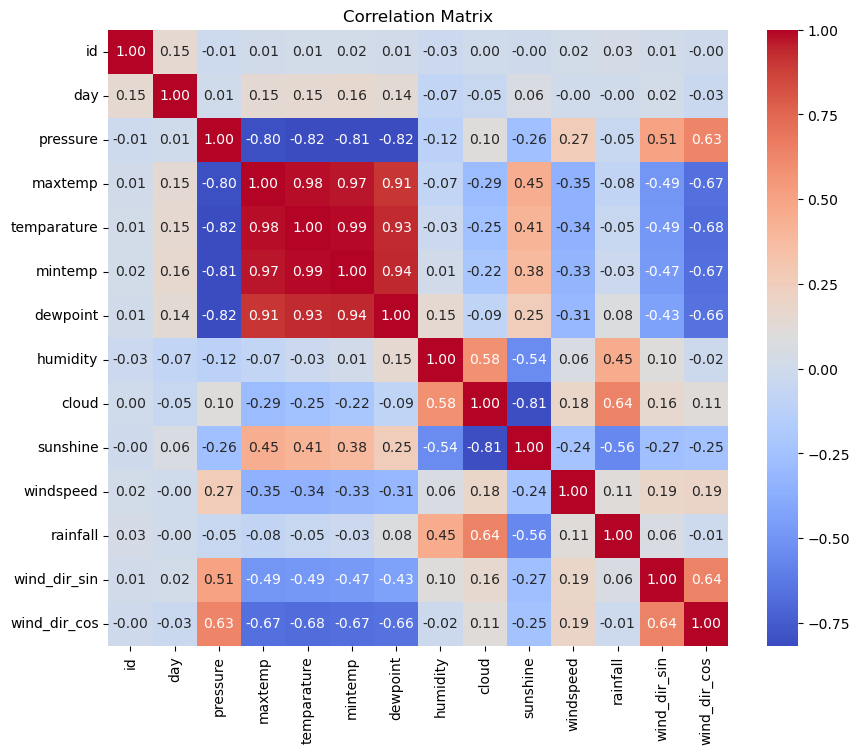

In [20]:
# HeatMap

plt.figure(figsize=(10, 8))

sns.heatmap(train.corr(), annot=True, cmap= 'coolwarm', fmt= '.2f')

plt.title("Correlation Matrix")
plt.show()

In [21]:
train['rainfall'].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

In [29]:
test_id = test['id']

# Data preprocessing

In [30]:
# Drop highly correlated columns to avoid multicollinearity
drop_cols = ['maxtemp','temparature','mintemp','rainfall','day','id'] 

X = train.drop(columns=drop_cols)

y = train['rainfall']

X_test_final = test.drop(columns=drop_cols, errors='ignore')

In [31]:
num_cols = X.columns.tolist()

In [33]:
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols)
], remainder="drop")

# Train-Validation Split

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
print("Original class distribution:", Counter(y_train))

Original class distribution: Counter({1: 1320, 0: 432})


# Random Oversampling for Imbalance

In [36]:
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
print("After Oversampling:", Counter(y_train_res))

After Oversampling: Counter({1: 1320, 0: 1320})


# **Model Building & Evaluation**


=== Logistic Regression ===
Validation ROC-AUC: 0.8789
Best Threshold (Youden's J): 0.4835
Accuracy (threshold 0.5): 0.8401826484018264
Accuracy (optimal threshold): 0.8515981735159818

Classification Report (optimal threshold):
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       108
           1       0.92      0.88      0.90       330

    accuracy                           0.85       438
   macro avg       0.80      0.82      0.81       438
weighted avg       0.86      0.85      0.85       438

Confusion Matrix:
 [[ 81  27]
 [ 38 292]]

=== Random Forest ===
Validation ROC-AUC: 0.8789
Best Threshold (Youden's J): 0.4216
Accuracy (threshold 0.5): 0.8356164383561644
Accuracy (optimal threshold): 0.865296803652968

Classification Report (optimal threshold):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       108
           1       0.91      0.91      0.91       330

    accuracy  

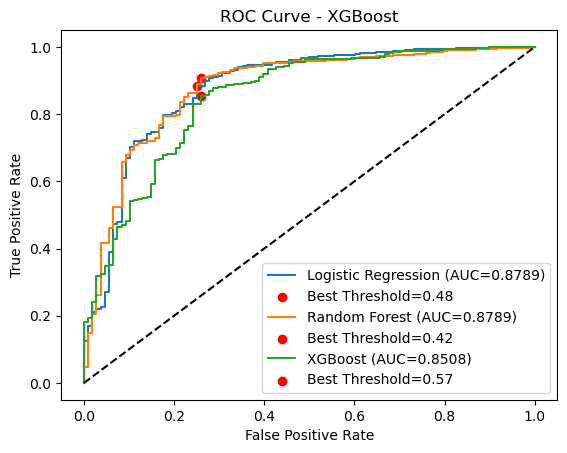

In [58]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', penalty='l2', random_state=42, max_iter=1500),
    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth= 5,random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.3, max_depth=3, random_state=42)
}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('clf', model)
    ])

    # Fit on oversampled training set
    pipe.fit(X_train_res, y_train_res)

    # Validation predictions (for threshold)
    y_proba = pipe.predict_proba(X_valid)[:,1]

    # Validation predictions (for default =0.5)
    y_pred = pipe.predict(X_valid)

    # ROC-AUC & Optimal Threshold

    fpr, tpr, threshold = roc_curve(y_valid, y_proba) 
    auc = roc_auc_score(y_valid, y_proba)

    j_scores = tpr - fpr 
    best_idx = np.argmax(j_scores)
    best_thresh = threshold[best_idx]

    # Apply optimal Threshold 

    y_pred_opt = (y_proba >= best_thresh).astype(int)

    print(f"\n=== {name} ===")
    print(f"Validation ROC-AUC: {auc:.4f}")
    print(f"Best Threshold (Youden's J): {best_thresh:.4f}")
    print("Accuracy (threshold 0.5):", accuracy_score(y_valid, y_pred))
    print("Accuracy (optimal threshold):", accuracy_score(y_valid, y_pred_opt))
    print("\nClassification Report (optimal threshold):")
    print(classification_report(y_valid, y_pred_opt))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_opt))

    # Plot ROC curve with best threshold point

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f"Best Threshold={best_thresh:.2f}")

# Plot ROC curve

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {name}")
plt.legend()
plt.show()

    



# Final Model Training on Full Data

In [59]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300,max_depth= 5,random_state=42))
])

In [60]:
# Fit on full data with oversampling
X_res_full, y_res_full = ros.fit_resample(X, y)

In [61]:
final_pipe.fit(X_res_full, y_res_full)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Predict on Test Data

In [62]:
# Using Optimal Threshold
y_test_proba = final_pipe.predict_proba(X_test_final)[:,1]
y_final_pred = (y_test_proba >= best_thresh).astype(int)

# Using 0.5 default Threshold
y_default_pred = final_pipe.predict(X_test_final)

# Save submission

In [63]:
submission = pd.DataFrame({
    "id": test_id,  # or df_test['Id'] if Kaggle provides IDs
    "rainfall": y_final_pred   # or y_default_pred if you want default-based  # 'rainfall' : le.inverse_transform(y_final_pred)
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")


✅ submission.csv saved!


In [64]:
import pickle

# Save the trained pipeline
with open("rainfall_model.pkl", "wb") as f:
    pickle.dump(final_pipe, f)

print("✅ Model saved as rainfall_model.pkl")


✅ Model saved as rainfall_model.pkl
